# The Lorenz Differential Equations

Before we start, we import some preliminary libraries. We will also import (below) the accompanying `lorenz.py` file, which contains the actual solver and plotting routine.

In [1]:
import matplotlib.pyplot as plt
plt.style.use('classic')
%matplotlib inline
# %matplotlib widget

from ipywidgets import interactive, fixed

In [2]:
import matplotlib.pyplot as plt
from ipywidgets import interact, interactive
from IPython.display import clear_output, display, HTML
import numpy as np
from scipy import integrate

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import cnames
from matplotlib import animation

We explore the Lorenz system of differential equations:

$$
\begin{aligned}
\dot{x} & = \sigma(y-x) \\
\dot{y} & = \rho x - y - xz \\
\dot{z} & = -\beta z + xy
\end{aligned}
$$

Let's change (\\(\sigma\\), \\(\beta\\), \\(\rho\\)) with ipywidgets and examine the trajectories.

In [3]:
def solve_lorenz(N=10, angle=0.0, max_time=4.0, sigma=10.0, beta=8./3, rho=28.0):

    fig = plt.figure()
    ax = fig.add_axes([0, 0, 1, 1], projection='3d')
    ax.axis('off')

    # prepare the axes limits
    ax.set_xlim((-25, 25))
    ax.set_ylim((-35, 35))
    ax.set_zlim((5, 55))

    def lorenz_deriv(x_y_z, t0, sigma=sigma, beta=beta, rho=rho):
        """Compute the time-derivative of a Lorenz system."""
        x, y, z = x_y_z
        return [sigma * (y - x), x * (rho - z) - y, x * y - beta * z]

    # Choose random starting points, uniformly distributed from -15 to 15
    np.random.seed(1)
    x0 = -15 + 30 * np.random.random((N, 3))

    # Solve for the trajectories
    t = np.linspace(0, max_time, int(250*max_time))
    x_t = np.asarray([integrate.odeint(lorenz_deriv, x0i, t)
                      for x0i in x0])

    # choose a different color for each trajectory
    colors = plt.cm.viridis(np.linspace(0, 1, N))

    for i in range(N):
        x, y, z = x_t[i,:,:].T
        lines = ax.plot(x, y, z, '-', c=colors[i])
        plt.setp(lines, linewidth=2)

    ax.view_init(30, angle)
    plt.show()

    return t, x_t

In [4]:
# from lorenz import solve_lorenz
w = interactive(solve_lorenz, sigma=(0.0,50.0), rho=(0.0,50.0))
w

interactive(children=(IntSlider(value=10, description='N', max=30, min=-10), FloatSlider(value=0.0, descriptio…

For the default set of parameters, we see the trajectories swirling around two points, called attractors. 

The object returned by `interactive` is a `Widget` object and it has attributes that contain the current result and arguments:

In [6]:
t, x_t = w.result

In [7]:
w.kwargs

{'N': 10,
 'angle': 0.0,
 'max_time': 4.0,
 'sigma': 10.0,
 'beta': 2.6666666666666665,
 'rho': 28.0}

After interacting with the system, we can take the result and perform further computations. In this case, we compute the average positions in \\(x\\), \\(y\\) and \\(z\\).

In [8]:
xyz_avg = x_t.mean(axis=1)

In [9]:
xyz_avg.shape

(10, 3)

Creating histograms of the average positions (across different trajectories) show that, on average, the trajectories swirl about the attractors.

In [10]:
from matplotlib import pyplot as plt

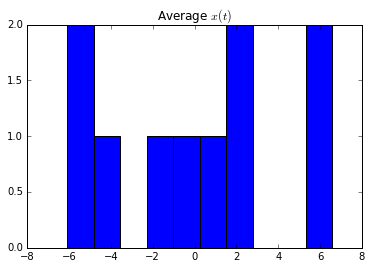

In [11]:
plt.hist(xyz_avg[:,0])
plt.title('Average $x(t)$');

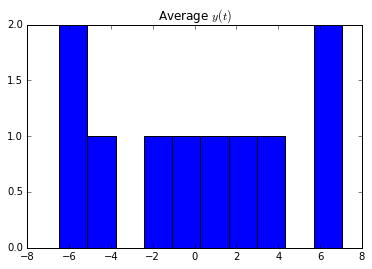

In [12]:
plt.hist(xyz_avg[:,1])
plt.title('Average $y(t)$');